In [18]:
!pip install gymnasium


In [19]:
from __future__ import annotations
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec


def build_env(map_name: str = "8x8", slippery: bool = True):
	return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery)


def extract_model(env: gym.Env, reward_schedule: str = "default"):
	"""
	Build the (transition, reward, expected_reward) tensors from the
	Gymnasium FrozenLake model.

	reward_schedule options
	-----------------------
	"default"      : +1 at goal only (original sparse reward)
	"step_penalty"  : +1 at goal, -0.01 per step
	"dense"         : +1 goal, -1 hole, -0.04 per step
	"""
	n_states  = env.observation_space.n
	n_actions = env.action_space.n
	transition      = np.zeros((n_states, n_actions, n_states), dtype=float)
	reward          = np.zeros((n_states, n_actions, n_states), dtype=float)
	desc = np.asarray(env.unwrapped.desc, dtype=str).flatten()

	for state in range(n_states):
		for action in range(n_actions):
			for prob, next_state, r, _terminated in env.unwrapped.P[state][action]:
				transition[state, action, next_state] += prob
				if reward_schedule == "default":
					reward[state, action, next_state] = r
				elif reward_schedule == "step_penalty":
					reward[state, action, next_state] = r - 0.01
				elif reward_schedule == "dense":
					if desc[next_state] == "H":
						reward[state, action, next_state] = -1.0
					elif desc[next_state] == "G":
						reward[state, action, next_state] = 1.0
					else:
						reward[state, action, next_state] = -0.04

	expected_reward = np.sum(transition * reward, axis=2)
	return transition, reward, expected_reward


In [20]:
def value_iteration(transition, expected_reward, gamma=0.99, epsi=1e-9):

	n_s, n_a = transition.shape[:2]
	v = np.zeros(n_s)
	deltas = []

	while True:
		q = np.zeros((n_s, n_a))
		for s in range(n_s):
			for a in range(n_a):
				q[s, a] = expected_reward[s, a] + gamma * np.sum(transition[s, a, :] * v)

		vnew = np.max(q, axis=1)
		delta = np.max(np.abs(vnew - v))
		deltas.append(delta)

		if delta < epsi:
			v = vnew
			break
		v = vnew

	p = np.argmax(q, axis=1)
	return p, deltas


In [21]:
def policy_iteration(transition, expected_reward, gamma=0.99, epsi=1e-9, episodes =10000):
	n_s, n_a = transition.shape[:2]
	policy = np.zeros(n_s, dtype=int)
	v = np.zeros(n_s)

	for i in range(episodes):
		while True:
			vnew = np.zeros(n_s)
			for s in range(n_s):
				a = policy[s]
				vnew[s] = expected_reward[s, a] + gamma * np.sum(transition[s, a, :] * v)
			if np.max(np.abs(vnew - v)) < epsi:
				v = vnew
				break
			v = vnew

		q = np.zeros((n_s, n_a))
		for s in range(n_s):
			for a in range(n_a):
				q[s, a] = expected_reward[s, a] + gamma * np.sum(transition[s, a, :] * v)

		new_policy = np.argmax(q, axis=1)
		if np.array_equal(policy, new_policy):
			break
		policy = new_policy

	return policy


In [22]:
def policy_iteration_matrix(transition, expected_reward, gamma=0.99, episodes =1000):
	n_s, n_a = transition.shape[:2]
	policy = np.zeros(n_s, dtype=int)

	for i in range(episodes):
		x = transition[np.arange(n_s), policy]
		r = expected_reward[np.arange(n_s), policy]

		y = np.eye(n_s) - gamma * x
		v = np.linalg.solve(y, r)

		q = np.zeros((n_s, n_a))
		for s in range(n_s):
			for a in range(n_a):
				q[s, a] = expected_reward[s, a] + gamma * np.sum(transition[s, a, :] * v)

		new_policy = np.argmax(q, axis=1)
		if np.array_equal(policy, new_policy):
			break
		policy = new_policy

	return policy


In [23]:
def montecarlo(env, gamma=0.99, episodes=50000):
	n_s, n_a = env.observation_space.n, env.action_space.n
	p = np.zeros(n_s, dtype=int)
	q = np.zeros((n_s, n_a))

	rsa = np.zeros((n_s, n_a))
	nsa = np.zeros((n_s, n_a))

	ep_rewards = []
	ep_lengths = []

	for i in range(episodes):
		env.reset()
		path = []
		s = env.observation_space.sample()
		a = env.action_space.sample()
		env.unwrapped.s = s

		for k in range(200):
			nexts, r, done, _, _ = env.step(a)
			path.append((s, a, r))
			if done: break
			s = nexts
			a = p[s]

		ep_rewards.append(sum(x[2] for x in path))
		ep_lengths.append(len(path))

		g = 0
		for state, action, reward in reversed(path):
			g = reward + gamma * g
			nsa[state, action] += 1
			rsa[state, action] += g
			q[state, action] = rsa[state, action] / nsa[state, action]
		p = np.argmax(q, axis=1)

	return p, q, ep_rewards, ep_lengths


In [24]:
def montecarlo_egreedy(env, gamma=0.99, exp=0.2, episodes=50000):
	n_s, n_a = env.observation_space.n, env.action_space.n
	p = np.ones((n_s, n_a)) / n_a
	q = np.zeros((n_s, n_a))

	rsa = np.zeros((n_s, n_a))
	nsa = np.zeros((n_s, n_a))

	ep_rewards = []
	ep_lengths = []

	for i in range(episodes):
		s = env.observation_space.sample()
		a = env.action_space.sample()
		env.reset()
		env.unwrapped.s = s
		path = []
		for k in range(200):
			nexts, r, done, _, _ = env.step(a)
			path.append((s, a, r))
			if done:
					break
			s = nexts
			a = np.random.choice(n_a, p=p[s])

		ep_rewards.append(sum(x[2] for x in path))
		ep_lengths.append(len(path))

		g = 0
		for state, action, reward in reversed(path):
			g = reward + gamma * g
			nsa[state, action] += 1
			rsa[state, action] += g
			q[state, action] = rsa[state, action] / nsa[state, action]

		for s in range(n_s):
			ba = np.argmax(q[s])
			p[s] = exp / n_a
			p[s, ba] += (1 - exp)

	policy = np.argmax(q, axis=1)

	return policy, q, ep_rewards, ep_lengths


In [25]:
# ── Plotting helpers ──────────────────────────────────────────────────────

ARROWS     = {0: "←", 1: "↓", 2: "→", 3: "↑"}
TILE_COLORS = {
	"S": "#9be7a1",
	"F": "#dceefb",
	"H": "#3a3a3a",
	"G": "#ffd54f",
}


def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy", ax=None):
	"""
	Draw the grid-world with colour-coded tiles and directional arrows.
	Can plot onto an existing Axes (ax) or create its own figure.
	"""
	desc         = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid  = np.asarray(policy).reshape(desc.shape)
	rows, cols   = desc.shape

	stand_alone = ax is None
	if stand_alone:
		fig, ax = plt.subplots(figsize=(8, 8))

	for r in range(rows):
		for c in range(cols):
			tile = desc[r, c]
			rect = mpatches.FancyBboxPatch(
				(c + 0.04, rows - 1 - r + 0.04), 0.92, 0.92,
				boxstyle="round,pad=0.03",
				facecolor=TILE_COLORS[tile], edgecolor="black", linewidth=1.2
			)
			ax.add_patch(rect)

			if tile == "H":
				label, clr = "✕", "white"
			elif tile == "G":
				label, clr = "★", "#333"
			else:
				label, clr = ARROWS[policy_grid[r, c]], "#1a1a2e"

			ax.text(c + 0.5, rows - 1 - r + 0.5, label,
				    ha="center", va="center", fontsize=14,
				    fontweight="bold", color=clr)

	ax.set_xlim(0, cols)
	ax.set_ylim(0, rows)
	ax.set_xticks([]); ax.set_yticks([])
	ax.set_aspect("equal")
	ax.set_title(title, fontsize=11, fontweight="bold", pad=6)

	if stand_alone:
		legend_elements = [
			mpatches.Patch(facecolor=TILE_COLORS["S"], edgecolor="black", label="S: Start"),
			mpatches.Patch(facecolor=TILE_COLORS["F"], edgecolor="black", label="F: Frozen"),
			mpatches.Patch(facecolor=TILE_COLORS["H"], edgecolor="black", label="H: Hole"),
			mpatches.Patch(facecolor=TILE_COLORS["G"], edgecolor="black", label="G: Goal"),
		]
		plt.legend(handles=legend_elements, loc="lower center",
		           ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.06))
		plt.tight_layout()
		plt.show()


def smooth(arr, window=100):
	"""Rolling mean for smoothing noisy training curves."""
	if len(arr) <= window:
		return np.array(arr)
	return np.convolve(arr, np.ones(window) / window, mode="valid")


def plot_all_policies(env, policies: dict, gamma: float = 0.99):
	"""
	Plot all algorithm policies side-by-side in one figure.
	policies: dict of {label: policy_array}
	"""
	n = len(policies)
	fig, axes = plt.subplots(1, n, figsize=(5 * n, 5.5))
	fig.patch.set_facecolor("#f7f9fc")

	for ax, (label, policy) in zip(axes, policies.items()):
		ax.set_facecolor("#f7f9fc")
		plot_policy_on_frozen_lake(env, policy, title=label, ax=ax)

	legend_elements = [
		mpatches.Patch(facecolor=TILE_COLORS["S"], edgecolor="black", label="S: Start"),
		mpatches.Patch(facecolor=TILE_COLORS["F"], edgecolor="black", label="F: Frozen"),
		mpatches.Patch(facecolor=TILE_COLORS["H"], edgecolor="black", label="H: Hole"),
		mpatches.Patch(facecolor=TILE_COLORS["G"], edgecolor="black", label="G: Goal"),
	]
	fig.legend(handles=legend_elements, loc="lower center", ncol=4,
	           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
	fig.suptitle(f"FrozenLake 8×8 — All Policies (γ={gamma}, slippery)",
	             fontsize=14, fontweight="bold", y=1.02)
	plt.tight_layout()
	plt.show()


def plot_mc_metrics(ep_rewards_list, ep_lengths_list, labels, window=100):
	"""
	Plot smoothed reward-per-episode and episode-length curves
	for one or more MC runs on the same axes.
	"""
	palette = ["#4e8df5", "#e05c5c", "#2ecc71", "#e67e22"]
	fig, (ax_r, ax_l) = plt.subplots(1, 2, figsize=(14, 4))
	fig.patch.set_facecolor("#f7f9fc")
	fig.suptitle("Monte Carlo Training Metrics", fontsize=13, fontweight="bold")

	for er, el, label, clr in zip(ep_rewards_list, ep_lengths_list, labels, palette):
		for ax, data, ylabel in [(ax_r, er, "Total Reward"),
		                          (ax_l, el, "Steps")]:
			sm = smooth(data, window)
			x  = np.arange(len(sm)) + window // 2
			ax.plot(data, color=clr, alpha=0.12, linewidth=0.4)
			ax.plot(x, sm, color=clr, linewidth=2.0, label=label)
			ax.set_xlabel("Episode")
			ax.set_ylabel(ylabel)
			ax.set_facecolor("#f7f9fc")
			ax.legend(fontsize=8)

	ax_r.set_title(f"Avg Reward / Episode (smoothed w={window})")
	ax_l.set_title(f"Avg Episode Length (smoothed w={window})")
	plt.tight_layout()
	plt.show()


def plot_vi_convergence(deltas):
	"""Plot max |ΔV| per iteration for value iteration (log scale)."""
	fig, ax = plt.subplots(figsize=(8, 4))
	fig.patch.set_facecolor("#f7f9fc")
	ax.set_facecolor("#f7f9fc")
	ax.semilogy(deltas, color="#4e8df5", linewidth=2)
	ax.axhline(1e-9, color="red", linestyle="--", linewidth=1, label="ε = 1e-9")
	ax.set_title("Value Iteration — Max |ΔV| per Iteration (log scale)",
	             fontweight="bold")
	ax.set_xlabel("Iteration")
	ax.set_ylabel("Max |ΔV|")
	ax.legend()
	plt.tight_layout()
	plt.show()


def plot_gamma_comparison(env, transition, expected_reward, gammas=(0.5, 0.8, 0.95, 0.99)):
	"""Run VI with different discount factors and compare policies + eval metrics."""
	n = len(gammas)
	fig, axes = plt.subplots(1, n, figsize=(5 * n, 5.5))
	fig.patch.set_facecolor("#f7f9fc")
	fig.suptitle("Effect of Discount Factor γ on Value Iteration Policy",
	             fontsize=13, fontweight="bold")

	for ax, g in zip(axes, gammas):
		pol, _ = value_iteration(transition, expected_reward, gamma=g)
		avg_r, avg_l = evaluate_policy(env, pol)
		ax.set_facecolor("#f7f9fc")
		plot_policy_on_frozen_lake(
			env, pol,
			title=f"γ = {g}\nSucc.={avg_r:.1%}  Steps={avg_l:.1f}",
			ax=ax
		)

	plt.tight_layout()
	plt.show()


def plot_reward_schedule_comparison(env, transition, gamma=0.99):
	"""Run VI under different reward schedules and compare policies + bar chart."""
	schedules = ["default", "step_penalty", "dense"]
	slabels   = ["Default\n(+1 goal only)",
	              "Step Penalty\n(+1 goal −0.01/step)",
	              "Dense\n(+1 goal −1 hole −0.04/step)"]

	fig = plt.figure(figsize=(18, 10))
	fig.patch.set_facecolor("#f7f9fc")
	fig.suptitle("Effect of Reward Schedule on Value Iteration Policy (γ=0.99)",
	             fontsize=13, fontweight="bold")
	gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.25)

	success_rates, avg_lengths = [], []
	for i, (sched, slabel) in enumerate(zip(schedules, slabels)):
		_, _, ER_s = extract_model(env, reward_schedule=sched)
		pol, _    = value_iteration(transition, ER_s, gamma=gamma)
		avg_r, avg_l = evaluate_policy(env, pol)
		success_rates.append(avg_r)
		avg_lengths.append(avg_l)

		ax_g = fig.add_subplot(gs[0, i])
		ax_g.set_facecolor("#f7f9fc")
		plot_policy_on_frozen_lake(
			env, pol,
			title=f"{slabel}\nSucc.={avg_r:.1%}  Steps={avg_l:.1f}",
			ax=ax_g
		)

	ax_bar  = fig.add_subplot(gs[1, :])
	ax_bar2 = ax_bar.twinx()
	ax_bar.set_facecolor("#f7f9fc")
	x = np.arange(len(schedules))
	ax_bar.bar(x - 0.2,  success_rates, 0.35, label="Success Rate",
	            color="#4e8df5", alpha=0.85)
	ax_bar2.bar(x + 0.2, avg_lengths,   0.35, label="Avg Steps",
	             color="#e05c5c", alpha=0.85)
	ax_bar.set_xticks(x)
	ax_bar.set_xticklabels([s.replace("\\n", " ") for s in slabels], fontsize=9)
	ax_bar.set_ylabel("Success Rate",  color="#4e8df5")
	ax_bar2.set_ylabel("Avg Steps",    color="#e05c5c")
	ax_bar.set_title("Reward Schedule Comparison (500 eval episodes)",
	                  fontsize=10, fontweight="bold")
	ax_bar.legend(loc="upper left")
	ax_bar2.legend(loc="upper right")
	plt.show()


In [26]:
def evaluate_policy(env, policy, n_eval=500, max_steps=200):
	"""
	Roll out a deterministic greedy policy and return
	(mean reward, mean episode length) over n_eval episodes.
	"""
	rewards, lengths = [], []
	for _ in range(n_eval):
		s, _ = env.reset()
		total_r, steps = 0, 0
		for _ in range(max_steps):
			s, r, done, _, _ = env.step(int(policy[s]))
			total_r += r
			steps   += 1
			if done: break
		rewards.append(total_r)
		lengths.append(steps)
	return np.mean(rewards), np.mean(lengths)


FrozenLake-v1 8x8 model
states: 64, actions: 4
Legend: S=start F=frozen H=hole G=goal  arrow=optimal action
Actions: 0=← 1=↓ 2=→ 3=↑


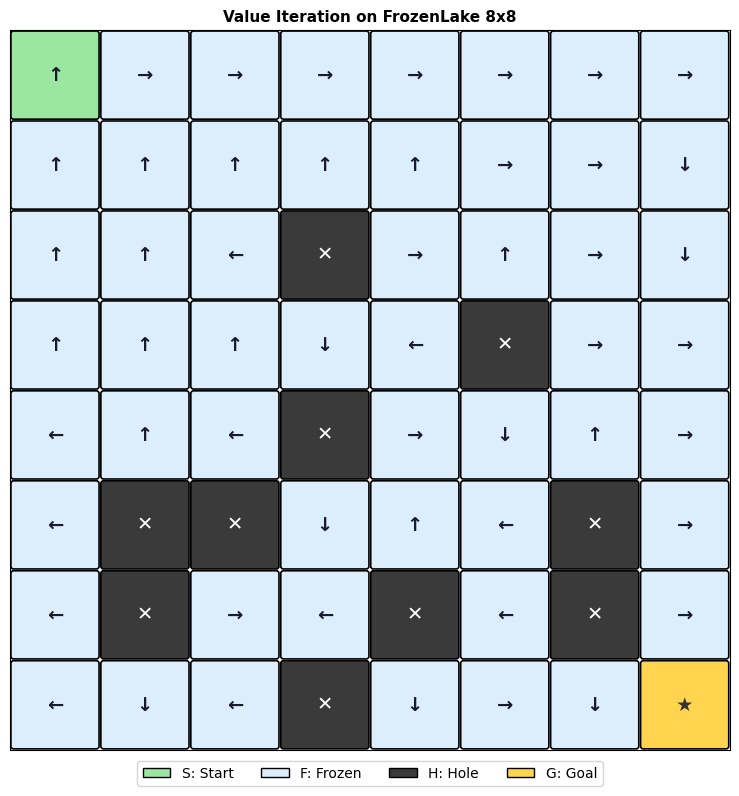

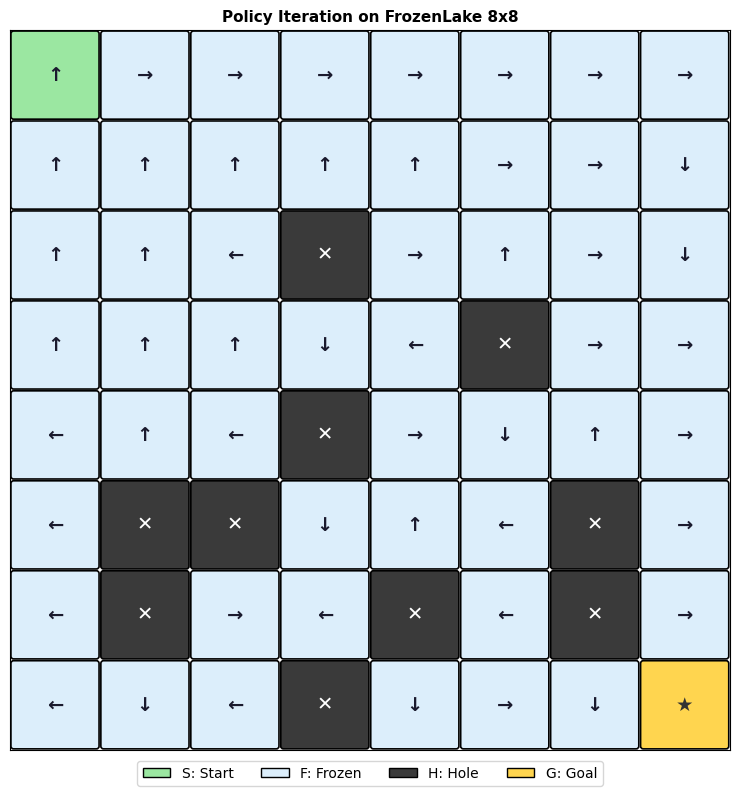

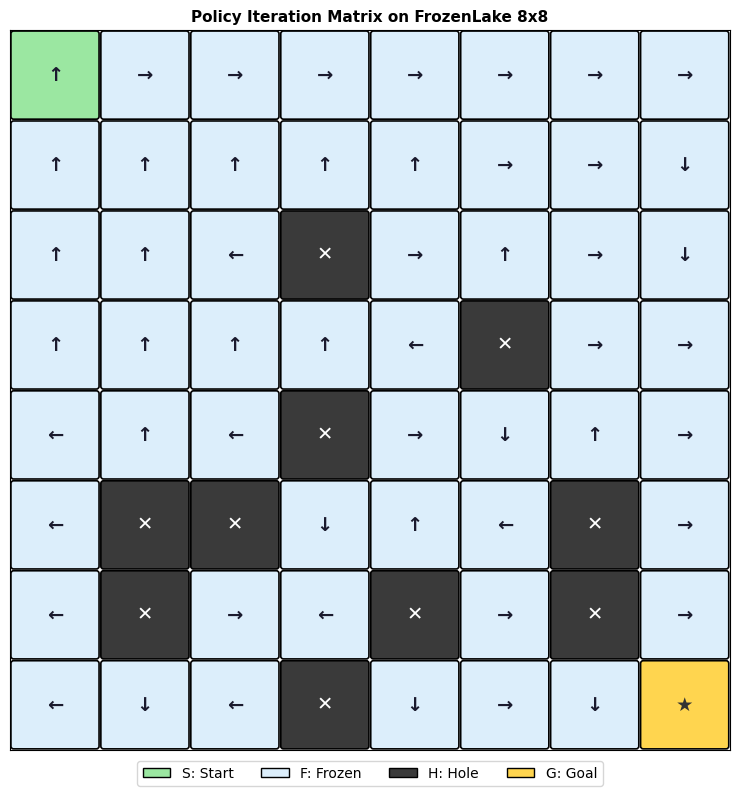

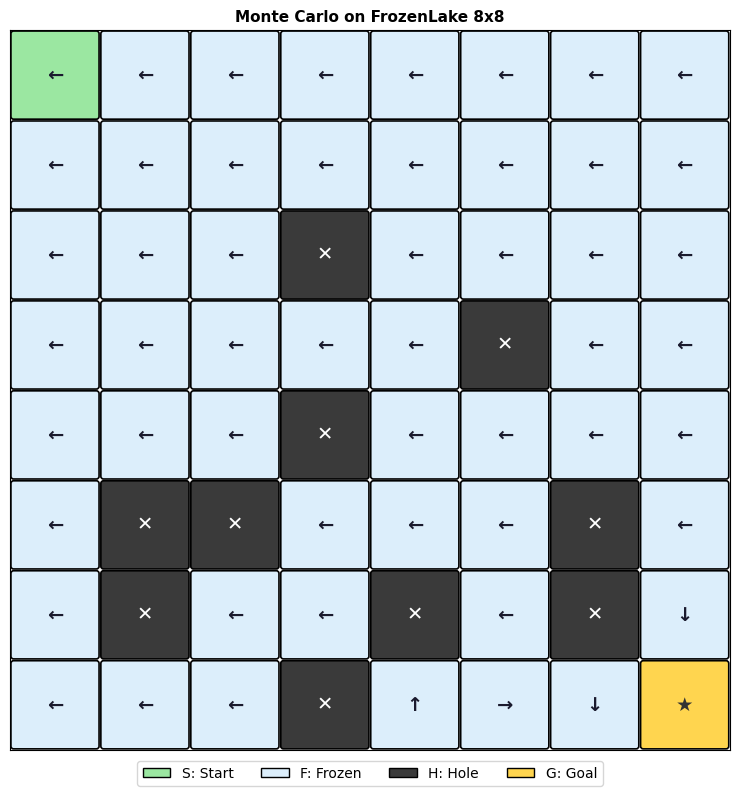

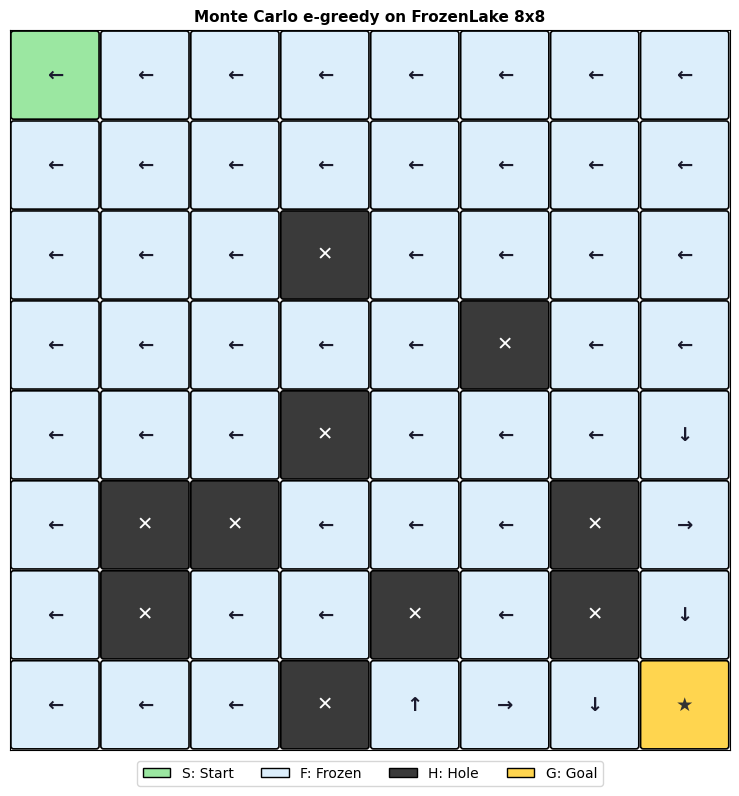

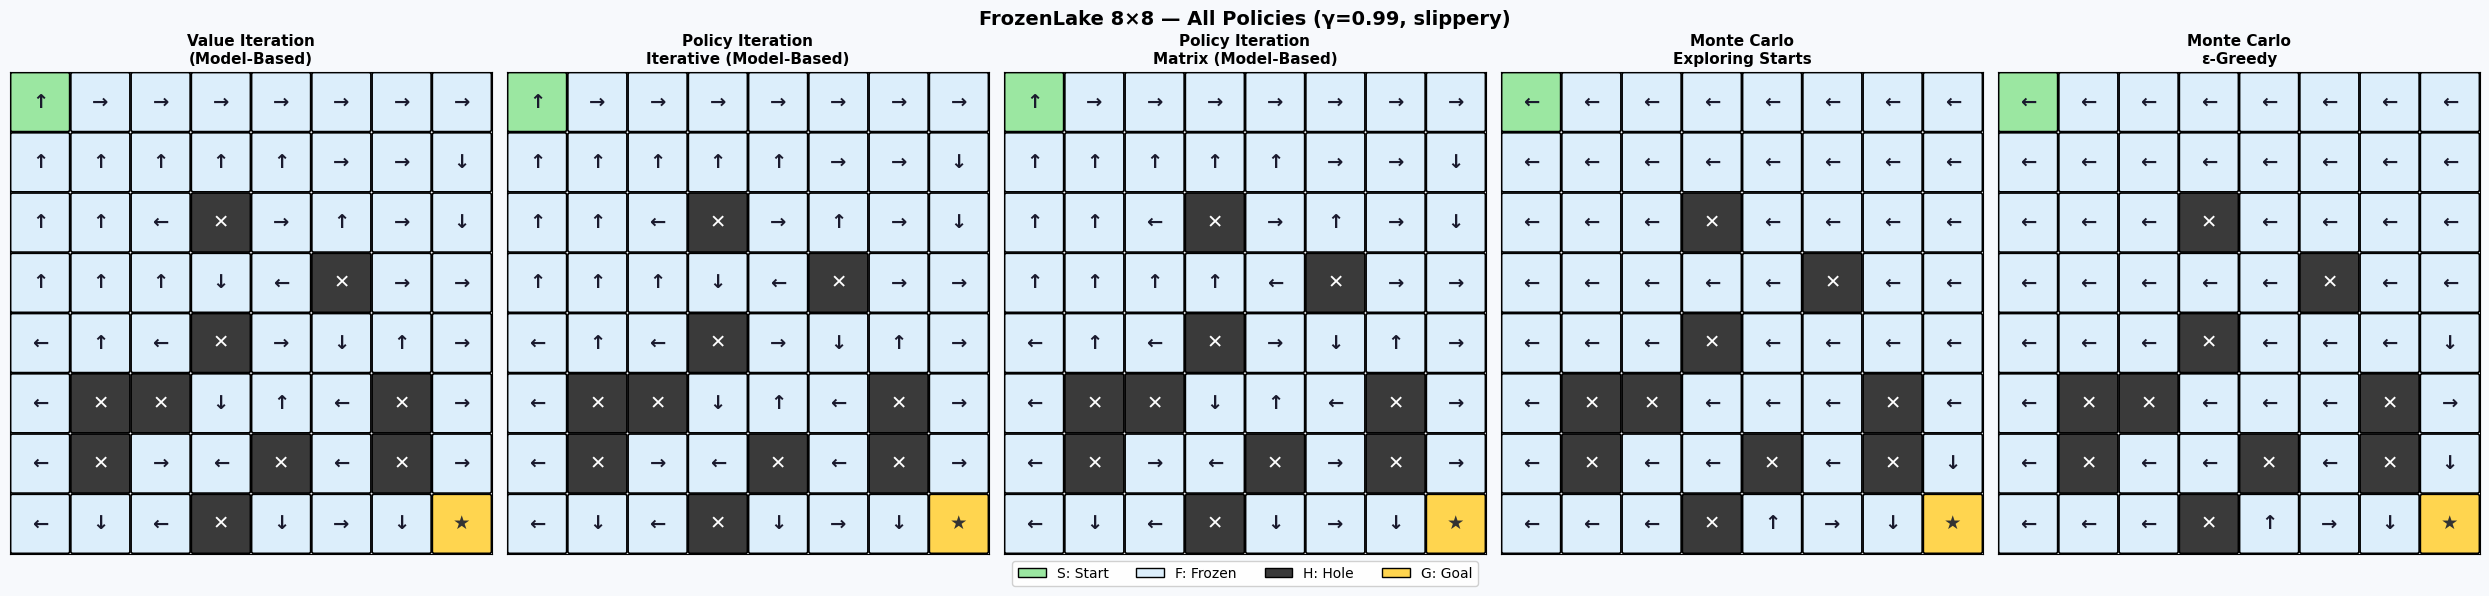

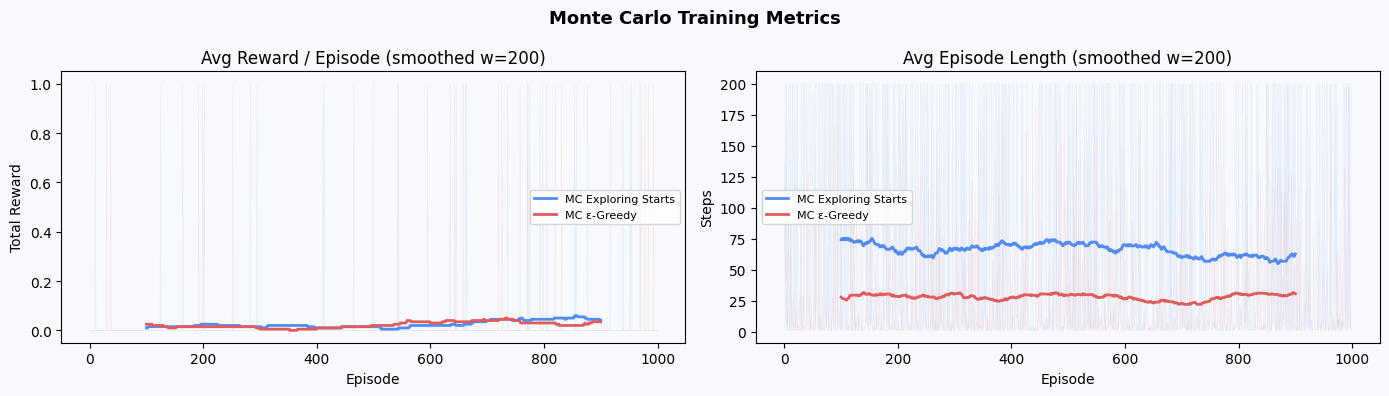

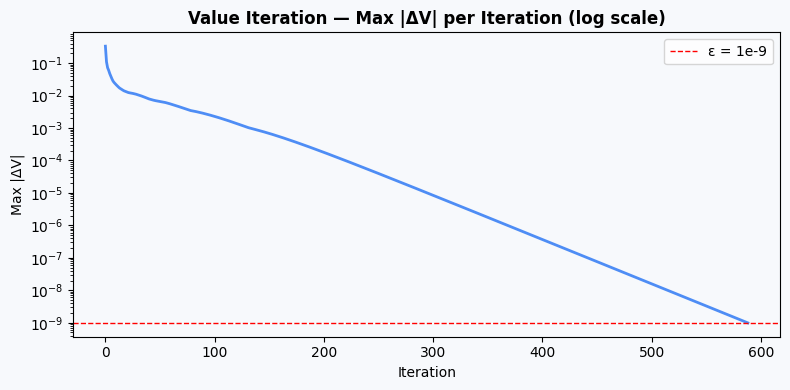

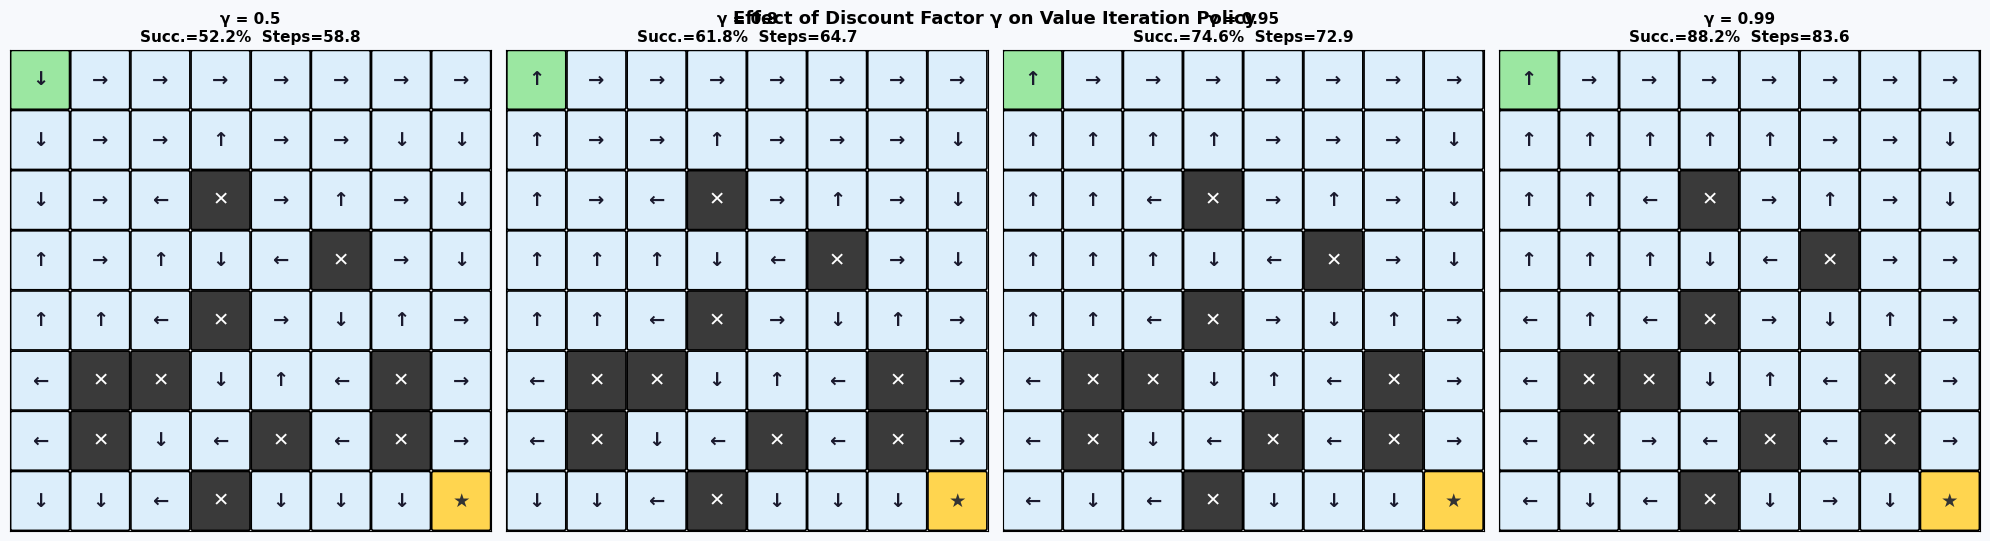

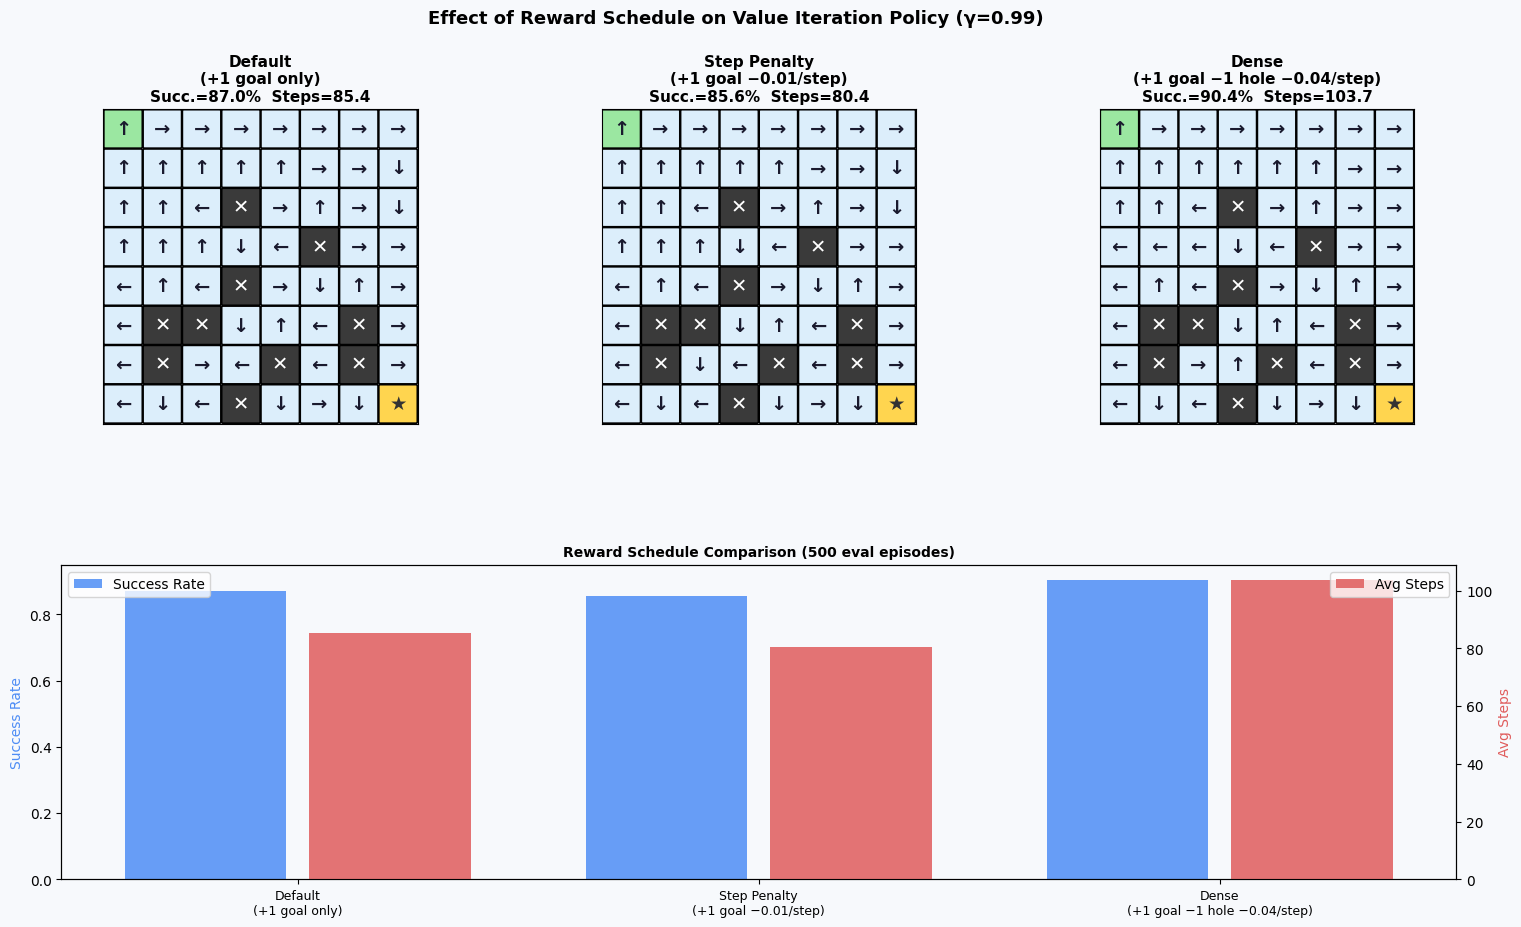

In [27]:
def main():
	gamma    = 0.99
	episodes = 1000
	env      = build_env(slippery=True)
	transition, reward, expected_reward = extract_model(env)

	print("FrozenLake-v1 8x8 model")
	print(f"states: {transition.shape[0]}, actions: {transition.shape[1]}")
	print("Legend: S=start F=frozen H=hole G=goal  arrow=optimal action")
	print("Actions: 0=← 1=↓ 2=→ 3=↑")

	# ── Model-Based ────────────────────────────────────────────────────────
	vi_policy, vi_deltas = value_iteration(transition, expected_reward, gamma=gamma)
	env.reset()

	pi_policy = policy_iteration(transition, expected_reward, gamma=gamma)
	env.reset()

	pi_matrix_policy = policy_iteration_matrix(transition, expected_reward, gamma=gamma)
	env.reset()

	# ── Model-Free ─────────────────────────────────────────────────────────
	mc_policy, _, mc_rewards, mc_lengths = montecarlo(env, gamma=gamma, episodes=episodes)
	env.reset()

	mcgreed_policy, _, mcgreed_rewards, mcgreed_lengths = montecarlo_egreedy(
		env, gamma=gamma, episodes=episodes
	)

	# ── Policy Grid Plots ──────────────────────────────────────────────────
	# Individual plots (original style)
	plot_policy_on_frozen_lake(env, vi_policy,        title="Value Iteration on FrozenLake 8x8")
	plot_policy_on_frozen_lake(env, pi_policy,        title="Policy Iteration on FrozenLake 8x8")
	plot_policy_on_frozen_lake(env, pi_matrix_policy, title="Policy Iteration Matrix on FrozenLake 8x8")
	plot_policy_on_frozen_lake(env, mc_policy,        title="Monte Carlo on FrozenLake 8x8")
	plot_policy_on_frozen_lake(env, mcgreed_policy,   title="Monte Carlo e-greedy on FrozenLake 8x8")

	# All policies side-by-side
	plot_all_policies(env, {
		"Value Iteration\n(Model-Based)":          vi_policy,
		"Policy Iteration\nIterative (Model-Based)": pi_policy,
		"Policy Iteration\nMatrix (Model-Based)":    pi_matrix_policy,
		"Monte Carlo\nExploring Starts":             mc_policy,
		"Monte Carlo\nε-Greedy":                    mcgreed_policy,
	}, gamma=gamma)

	# ── MC Training Metric Plots ───────────────────────────────────────────
	plot_mc_metrics(
		[mc_rewards, mcgreed_rewards],
		[mc_lengths, mcgreed_lengths],
		labels=["MC Exploring Starts", "MC ε-Greedy"],
		window=200,
	)

	# ── Value Iteration Convergence ────────────────────────────────────────
	plot_vi_convergence(vi_deltas)

	# ── Discount Factor Analysis ───────────────────────────────────────────
	plot_gamma_comparison(env, transition, expected_reward,
		                      gammas=(0.50, 0.80, 0.95, 0.99))

	# ── Reward Schedule Analysis ───────────────────────────────────────────
	plot_reward_schedule_comparison(env, transition, gamma=gamma)


if __name__ == "__main__":
	main()
